In [43]:
import numpy as np
import xarray as xr
import xesmf as xe
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import os
import pypdd

In [2]:
# Reference/grid files
ref_path       = "/glade/campaign/cesm/development/liwg/forAdvik/CISM3_initialization_AIS_08000.b_h_s_interp_median.m1for0bed.2025-03-03.nc"
cism_grid_path = "/glade/u/home/ifairuz/processed_paleo_data/CISM3_initialization_AIS_08000.LatLon.nc"

# iPI (present-day) - annual climatology
ipi_ann_path = "/glade/campaign/cesm/community/palwg/iCESM1.2-DeglacialSlice/b.e12.B1850C5.f19_g16.iPI.01/atm/climo/b.e12.B1850C5.f19_g16.iPI.01_ANN_climo.nc"

# LGM TS - 900 years, use last 100
lgm_ts_path = "/glade/campaign/cesm/community/palwg/iCESM1.2-DeglacialSlice/b.e12.B1850C5.f19_g16.i21ka.03/atm/proc/tseries/monthly/TS/b.e12.B1850C5.f19_g16.i21ka.03.cam.h0.TS.0001-0900.nc"

# LIG TS - years 451-501
lig_ts_path = "/glade/campaign/cesm/development/palwg/LastInterglacial/iCESM1.2/b.e12.B1850C5.f19_g16.iLIG127k.001/atm/proc/tseries/month_1/b.e12.B1850C5.f19_g16.iLIG127k.001.cam.h0.TS.045101-050012.nc"

# Output directory
out_dir = "/glade/u/home/advike/CESM_Regrid/"

In [3]:
ref        = xr.open_dataset(ref_path, decode_cf=False)
cism_grid  = xr.open_dataset(cism_grid_path)

x1_vals = ref["x1"].values
y1_vals = ref["y1"].values
lon2d   = ref["Lon1"].isel(time=0).values
lat2d   = ref["Lat1"].isel(time=0).values

# CISM target grid for xESMF
grid_cism = xr.Dataset({
    "lat": (("y1", "x1"), cism_grid["Lat1"].data),
    "lon": (("y1", "x1"), cism_grid["Lon1"].data)
})

# Reference present-day surface temperature
ref_ts = ref["artm"].isel(time=0).values.astype("float64")
ref_ts = np.where(ref_ts == -99999, np.nan, ref_ts)

print("Reference artm range:", np.nanmin(ref_ts), "to", np.nanmax(ref_ts), "°C")

Reference artm range: -58.074554443359375 to 7.778583526611328 °C


In [4]:
ipi_ann = xr.open_dataset(ipi_ann_path)

# Crop to Antarctica
ipi_ts = ipi_ann["TS"].sel(lat=slice(-90, -50))
print("iPI TS shape:", ipi_ts.shape)
print("iPI TS units:", ipi_ts.attrs.get("units", "?"))
print("iPI TS range:", float(ipi_ts.min()), "to", float(ipi_ts.max()), "K")

iPI TS shape: (1, 22, 144)
iPI TS units: K
iPI TS range: 213.8194580078125 to 283.1197509765625 K


In [5]:
lgm_ts_ds = xr.open_dataset(lgm_ts_path, use_cftime=True)

# Use last 100 years (years 801-900 = last 1200 months)
lgm_ts = lgm_ts_ds["TS"].isel(time=slice(-1200, None))
lgm_ts = lgm_ts.sel(lat=slice(-90, -50))

# Annual mean
lgm_ts_ann = lgm_ts.mean(dim="time")

print("LGM TS shape:", lgm_ts_ann.shape)
print("LGM TS range:", float(lgm_ts_ann.min()), "to", float(lgm_ts_ann.max()), "K")

/glade/derecho/scratch/advike/tmp/ipykernel_3255/1996112046.py:1: DeprecationWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg instead.
Example usage:
    time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
    ds = xr.open_dataset(decode_times=time_coder)

  lgm_ts_ds = xr.open_dataset(lgm_ts_path, use_cftime=True)


LGM TS shape: (22, 144)
LGM TS range: 206.9187774658203 to 278.29998779296875 K


In [6]:
lig_ts_ds = xr.open_dataset(lig_ts_path, use_cftime=True)

# Use all available years (451-501)
lig_ts = lig_ts_ds["TS"].sel(lat=slice(-90, -50))
lig_ts_ann = lig_ts.mean(dim="time")

print("LIG TS shape:", lig_ts_ann.shape)
print("LIG TS range:", float(lig_ts_ann.min()), "to", float(lig_ts_ann.max()), "K")

LIG TS shape: (22, 144)
LIG TS range: 214.23887634277344 to 283.1201477050781 K


/glade/derecho/scratch/advike/tmp/ipykernel_3255/2179468624.py:1: DeprecationWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg instead.
Example usage:
    time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
    ds = xr.open_dataset(decode_times=time_coder)

  lig_ts_ds = xr.open_dataset(lig_ts_path, use_cftime=True)


In [7]:
# Build source datasets for xESMF (need lat/lon as coordinates)
def make_src_ds(da):
    return xr.Dataset({"TS": da})

ipi_src = make_src_ds(ipi_ts.squeeze() if "time" in ipi_ts.dims else ipi_ts)
lgm_src = make_src_ds(lgm_ts_ann)
lig_src = make_src_ds(lig_ts_ann)

# Build regridders
ipi_regridder = xe.Regridder(ipi_src, grid_cism, method="bilinear", periodic=True)
lgm_regridder = xe.Regridder(lgm_src, grid_cism, method="bilinear", periodic=True)
lig_regridder = xe.Regridder(lig_src, grid_cism, method="bilinear", periodic=True)

# Regrid
ipi_ts_cism = ipi_regridder(ipi_src)["TS"].values - 273.15  # K to °C
lgm_ts_cism = lgm_regridder(lgm_src)["TS"].values - 273.15
lig_ts_cism = lig_regridder(lig_src)["TS"].values - 273.15

print("iPI TS on CISM grid:", ipi_ts_cism.shape, 
      f"range: {ipi_ts_cism.min():.2f} to {ipi_ts_cism.max():.2f} °C")
print("LGM TS on CISM grid:", lgm_ts_cism.shape,
      f"range: {lgm_ts_cism.min():.2f} to {lgm_ts_cism.max():.2f} °C")
print("LIG TS on CISM grid:", lig_ts_cism.shape,
      f"range: {lig_ts_cism.min():.2f} to {lig_ts_cism.max():.2f} °C")

iPI TS on CISM grid: (761, 761) range: -59.29 to 7.43 °C
LGM TS on CISM grid: (761, 761) range: -66.22 to 2.28 °C
LIG TS on CISM grid: (761, 761) range: -58.90 to 7.67 °C


In [8]:
# Compute anomalies
lgm_ts_anomaly = lgm_ts_cism - ipi_ts_cism
lig_ts_anomaly = lig_ts_cism - ipi_ts_cism

# Apply to RACMO present-day surface temperature
lgm_artm_final = ref_ts + lgm_ts_anomaly
lig_artm_final = ref_ts + lig_ts_anomaly

print("LGM artm final:", f"{np.nanmin(lgm_artm_final):.2f} to {np.nanmax(lgm_artm_final):.2f} °C")
print("LIG artm final:", f"{np.nanmin(lig_artm_final):.2f} to {np.nanmax(lig_artm_final):.2f} °C")
print("PD artm (ref):  ", f"{np.nanmin(ref_ts):.2f} to {np.nanmax(ref_ts):.2f} °C")

# Sanity check — LGM should be colder than PD, LIG warmer
print(f"\nMean LGM anomaly: {np.nanmean(lgm_ts_anomaly):.2f} °C (should be negative)")
print(f"Mean LIG anomaly: {np.nanmean(lig_ts_anomaly):.2f} °C (should be positive)")

LGM artm final: -65.32 to 2.60 °C
LIG artm final: -58.15 to 8.01 °C
PD artm (ref):   -58.07 to 7.78 °C

Mean LGM anomaly: -13.09 °C (should be negative)
Mean LIG anomaly: 0.35 °C (should be positive)


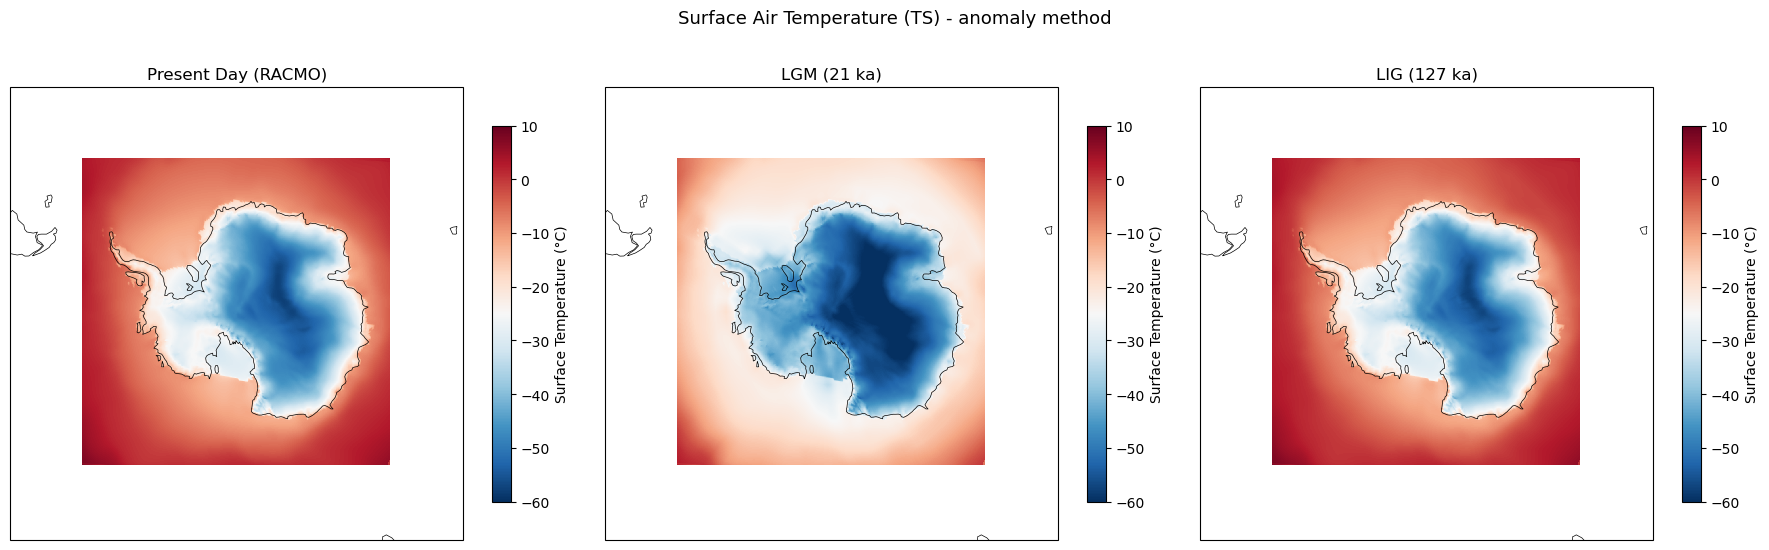

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6),
                         subplot_kw={"projection": ccrs.SouthPolarStereo()})

for ax, data, title in zip(axes,
                            [ref_ts, lgm_artm_final, lig_artm_final],
                            ["Present Day (RACMO)", "LGM (21 ka)", "LIG (127 ka)"]):
    ax.set_extent([-180, 180, -90, -50], ccrs.PlateCarree())
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
    p = ax.pcolormesh(lon2d, lat2d, data,
                      transform=ccrs.PlateCarree(),
                      cmap="RdBu_r", vmin=-60, vmax=10)
    plt.colorbar(p, ax=ax, label="Surface Temperature (°C)", shrink=0.7)
    ax.set_title(title)

plt.suptitle("Surface Air Temperature (TS) - anomaly method", fontsize=13)
plt.tight_layout()
plt.show()

In [24]:
lgm_precip_base = ("/glade/campaign/cesm/community/palwg/iCESM1.2-DeglacialSlice/"
                   "b.e12.B1850C5.f19_g16.i21ka.03/atm/proc/tseries/monthly/")
lig_precip_base = ("/glade/campaign/cesm/development/palwg/LastInterglacial/"
                   "iCESM1.2/b.e12.B1850C5.f19_g16.iLIG127k.001/atm/proc/tseries/month_1/")

# RACMO PD SMB — mask fill value, units already mm/yr
ref_smb = ref["smb"].isel(time=0).values.astype("float64")
ref_smb = np.where(ref_smb > 1e6, np.nan, ref_smb)
print(f"RACMO SMB: {np.nanmin(ref_smb):.1f} to {np.nanmax(ref_smb):.1f} mm/yr")

# iPI PRECIP — reuse ipi_ann already open
ipi_precip = (ipi_ann["PRECC"] + ipi_ann["PRECL"]).sel(lat=slice(-90, -50)).squeeze()
print(f"iPI PRECIP shape: {ipi_precip.shape}")

# LGM PRECIP — single file, last 100 years (isel matches TS convention)
lgm_precc = xr.open_dataset(lgm_precip_base + "PRECC/b.e12.B1850C5.f19_g16.i21ka.03.cam.h0.PRECC.0001-0900.nc", use_cftime=True)["PRECC"]
lgm_precl = xr.open_dataset(lgm_precip_base + "PRECL/b.e12.B1850C5.f19_g16.i21ka.03.cam.h0.PRECL.0001-0900.nc", use_cftime=True)["PRECL"]
lgm_precip = (lgm_precc + lgm_precl).isel(time=slice(-1200, None)).sel(lat=slice(-90, -50)).mean("time")
print(f"LGM PRECIP shape: {lgm_precip.shape}")

# LIG PRECIP — use same time window as TS (years 451-501, file 045101-050012)
lig_precc = xr.open_dataset(lig_precip_base + "b.e12.B1850C5.f19_g16.iLIG127k.001.cam.h0.PRECC.045101-050012.nc", use_cftime=True)["PRECC"]
lig_precl = xr.open_dataset(lig_precip_base + "b.e12.B1850C5.f19_g16.iLIG127k.001.cam.h0.PRECL.045101-050012.nc", use_cftime=True)["PRECL"]
lig_precip = (lig_precc + lig_precl).sel(lat=slice(-90, -50)).mean("time")
print(f"LIG PRECIP shape: {lig_precip.shape}")

RACMO SMB: -436.1 to 4764.4 mm/yr
iPI PRECIP shape: (22, 144)


/glade/derecho/scratch/advike/tmp/ipykernel_3255/533075872.py:16: DeprecationWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg instead.
Example usage:
    time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
    ds = xr.open_dataset(decode_times=time_coder)

  lgm_precc = xr.open_dataset(lgm_precip_base + "PRECC/b.e12.B1850C5.f19_g16.i21ka.03.cam.h0.PRECC.0001-0900.nc", use_cftime=True)["PRECC"]
/glade/derecho/scratch/advike/tmp/ipykernel_3255/533075872.py:17: DeprecationWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg instead.
Example usage:
    time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
    ds = xr.open_dataset(decode_times=time_coder)

  lgm_precl = xr.open_dataset(lgm_precip_base + "PRECL/b.e12.B1850C5.f19_g16.i21ka.03.cam.h0.PRECL.0001-0900.nc", use_cftime

LGM PRECIP shape: (22, 144)


/glade/derecho/scratch/advike/tmp/ipykernel_3255/533075872.py:22: DeprecationWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg instead.
Example usage:
    time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
    ds = xr.open_dataset(decode_times=time_coder)

  lig_precc = xr.open_dataset(lig_precip_base + "b.e12.B1850C5.f19_g16.iLIG127k.001.cam.h0.PRECC.045101-050012.nc", use_cftime=True)["PRECC"]
/glade/derecho/scratch/advike/tmp/ipykernel_3255/533075872.py:23: DeprecationWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg instead.
Example usage:
    time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
    ds = xr.open_dataset(decode_times=time_coder)

  lig_precl = xr.open_dataset(lig_precip_base + "b.e12.B1850C5.f19_g16.iLIG127k.001.cam.h0.PRECL.045101-050012.nc", use_cf

LIG PRECIP shape: (22, 144)


In [25]:
MS_TO_MM_YR = 1000.0 * 86400.0 * 365.0   # m/s → mm w.e./yr

def make_precip_src(da):
    return xr.Dataset({"PRECIP": da})

ipi_precip_rgr = xe.Regridder(make_precip_src(ipi_precip), grid_cism, method="bilinear", periodic=True)
lgm_precip_rgr = xe.Regridder(make_precip_src(lgm_precip), grid_cism, method="bilinear", periodic=True)
lig_precip_rgr = xe.Regridder(make_precip_src(lig_precip), grid_cism, method="bilinear", periodic=True)

ipi_precip_cism = ipi_precip_rgr(make_precip_src(ipi_precip))["PRECIP"].values
lgm_precip_cism = lgm_precip_rgr(make_precip_src(lgm_precip))["PRECIP"].values
lig_precip_cism = lig_precip_rgr(make_precip_src(lig_precip))["PRECIP"].values

print(f"iPI PRECIP on CISM: {ipi_precip_cism.shape}  mean: {ipi_precip_cism.mean()*MS_TO_MM_YR:.1f} mm/yr")
print(f"LGM PRECIP on CISM: {lgm_precip_cism.shape}  mean: {lgm_precip_cism.mean()*MS_TO_MM_YR:.1f} mm/yr")
print(f"LIG PRECIP on CISM: {lig_precip_cism.shape}  mean: {lig_precip_cism.mean()*MS_TO_MM_YR:.1f} mm/yr")

iPI PRECIP on CISM: (761, 761)  mean: 548.8 mm/yr
LGM PRECIP on CISM: (761, 761)  mean: 327.7 mm/yr
LIG PRECIP on CISM: (761, 761)  mean: 543.9 mm/yr


In [26]:
lgm_precip_anom = (lgm_precip_cism - ipi_precip_cism) * MS_TO_MM_YR
lig_precip_anom = (lig_precip_cism - ipi_precip_cism) * MS_TO_MM_YR

print(f"ΔPRECIP LGM mean: {np.nanmean(lgm_precip_anom):.1f} mm/yr  (expect negative)")
print(f"ΔPRECIP LIG mean: {np.nanmean(lig_precip_anom):.1f} mm/yr")

lgm_smb_final = ref_smb + lgm_precip_anom
lig_smb_final = ref_smb + lig_precip_anom

print(f"\nSMB LGM: {np.nanmin(lgm_smb_final):.1f} to {np.nanmax(lgm_smb_final):.1f} mm/yr")
print(f"SMB LIG: {np.nanmin(lig_smb_final):.1f} to {np.nanmax(lig_smb_final):.1f} mm/yr")
print(f"SMB PD:  {np.nanmin(ref_smb):.1f} to {np.nanmax(ref_smb):.1f} mm/yr")

ΔPRECIP LGM mean: -221.0 mm/yr  (expect negative)
ΔPRECIP LIG mean: -4.9 mm/yr

SMB LGM: -588.4 to 4519.7 mm/yr
SMB LIG: -425.4 to 4748.0 mm/yr
SMB PD:  -436.1 to 4764.4 mm/yr


In [27]:
lgm_precip_anom = (lgm_precip_cism - ipi_precip_cism) * MS_TO_MM_YR
lig_precip_anom = (lig_precip_cism - ipi_precip_cism) * MS_TO_MM_YR

print(f"ΔPRECIP LGM mean: {np.nanmean(lgm_precip_anom):.1f} mm/yr  (expect negative)")
print(f"ΔPRECIP LIG mean: {np.nanmean(lig_precip_anom):.1f} mm/yr")

lgm_smb_final = ref_smb + lgm_precip_anom
lig_smb_final = ref_smb + lig_precip_anom

print(f"\nSMB LGM: {np.nanmin(lgm_smb_final):.1f} to {np.nanmax(lgm_smb_final):.1f} mm/yr")
print(f"SMB LIG: {np.nanmin(lig_smb_final):.1f} to {np.nanmax(lig_smb_final):.1f} mm/yr")
print(f"SMB PD:  {np.nanmin(ref_smb):.1f} to {np.nanmax(ref_smb):.1f} mm/yr")

ΔPRECIP LGM mean: -221.0 mm/yr  (expect negative)
ΔPRECIP LIG mean: -4.9 mm/yr

SMB LGM: -588.4 to 4519.7 mm/yr
SMB LIG: -425.4 to 4748.0 mm/yr
SMB PD:  -436.1 to 4764.4 mm/yr


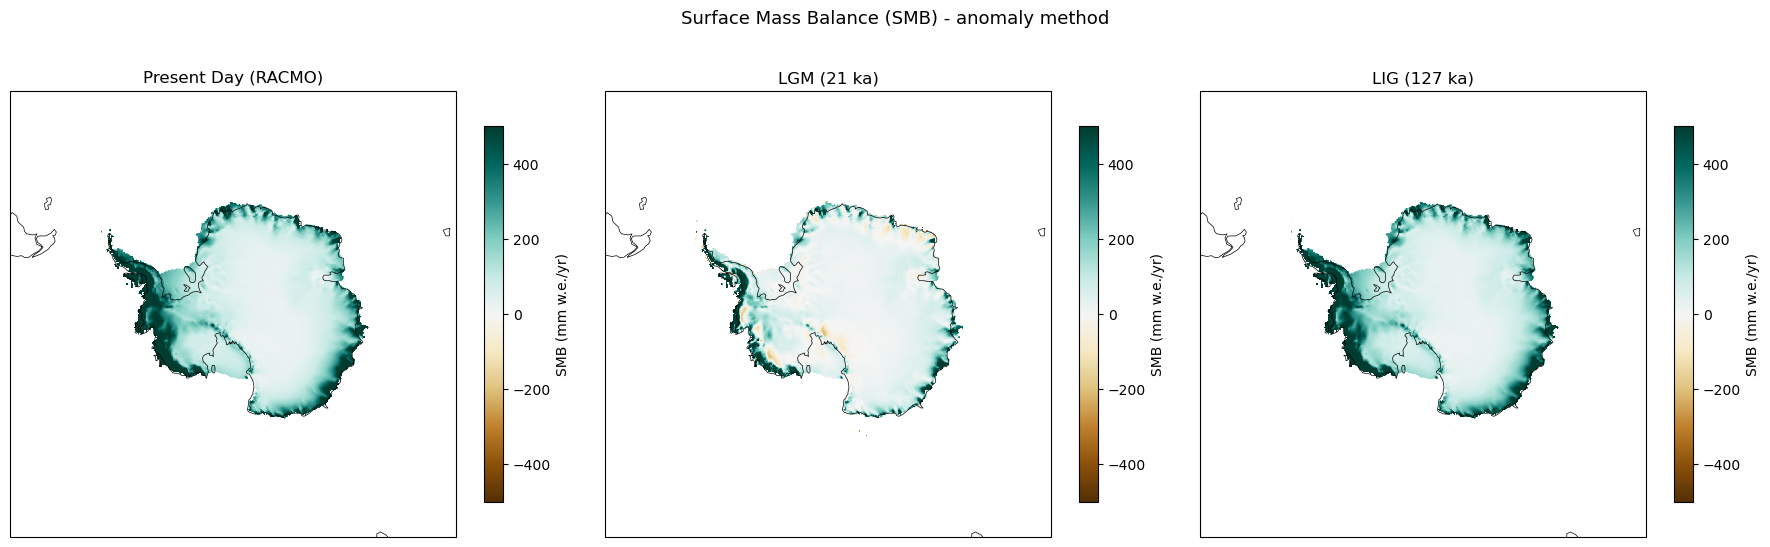

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6),
                         subplot_kw={"projection": ccrs.SouthPolarStereo()})

for ax, data, title in zip(axes,
                            [ref_smb, lgm_smb_final, lig_smb_final],
                            ["Present Day (RACMO)", "LGM (21 ka)", "LIG (127 ka)"]):
    ax.set_extent([-180, 180, -90, -50], ccrs.PlateCarree())
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
    p = ax.pcolormesh(lon2d, lat2d, data,
                      transform=ccrs.PlateCarree(),
                      cmap="BrBG", vmin=-500, vmax=500)
    plt.colorbar(p, ax=ax, label="SMB (mm w.e./yr)", shrink=0.7)
    ax.set_title(title)

plt.suptitle("Surface Mass Balance (SMB) - anomaly method", fontsize=13)
plt.tight_layout()
plt.show()

In [38]:
# 2m temperature — direct regrid, no anomaly method (no RACMO reference)

# iPI
ipi_trefht = ipi_ann["TREFHT"].sel(lat=slice(-90, -50)).squeeze()

# LGM — plain file, last 100 years
lgm_trefht = xr.open_dataset(
    lgm_precip_base + "TREFHT/b.e12.B1850C5.f19_g16.i21ka.03.cam.h0.TREFHT.0001-0900.nc",
    use_cftime=True
)["TREFHT"].isel(time=slice(-1200, None)).sel(lat=slice(-90, -50)).mean("time")

# LIG — same window as TS/PRECIP
lig_trefht = xr.open_dataset(
    lig_precip_base + "b.e12.B1850C5.f19_g16.iLIG127k.001.cam.h0.TREFHT.045101-050012.nc",
    use_cftime=True
)["TREFHT"].sel(lat=slice(-90, -50)).mean("time")

print(f"iPI TREFHT shape: {ipi_trefht.shape}  range: {float(ipi_trefht.min()):.1f} to {float(ipi_trefht.max()):.1f} K")
print(f"LGM TREFHT shape: {lgm_trefht.shape}  range: {float(lgm_trefht.min()):.1f} to {float(lgm_trefht.max()):.1f} K")
print(f"LIG TREFHT shape: {lig_trefht.shape}  range: {float(lig_trefht.min()):.1f} to {float(lig_trefht.max()):.1f} K")

/glade/derecho/scratch/advike/tmp/ipykernel_3255/2303241930.py:7: DeprecationWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg instead.
Example usage:
    time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
    ds = xr.open_dataset(decode_times=time_coder)

  lgm_trefht = xr.open_dataset(


iPI TREFHT shape: (22, 144)  range: 217.7 to 282.8 K
LGM TREFHT shape: (22, 144)  range: 208.6 to 277.1 K
LIG TREFHT shape: (22, 144)  range: 218.0 to 282.7 K


/glade/derecho/scratch/advike/tmp/ipykernel_3255/2303241930.py:13: DeprecationWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg instead.
Example usage:
    time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
    ds = xr.open_dataset(decode_times=time_coder)

  lig_trefht = xr.open_dataset(


In [39]:
def make_trefht_src(da):
    return xr.Dataset({"TREFHT": da})

ipi_trefht_rgr = xe.Regridder(make_trefht_src(ipi_trefht), grid_cism, method="bilinear", periodic=True)
lgm_trefht_rgr = xe.Regridder(make_trefht_src(lgm_trefht), grid_cism, method="bilinear", periodic=True)
lig_trefht_rgr = xe.Regridder(make_trefht_src(lig_trefht), grid_cism, method="bilinear", periodic=True)

ipi_trefht_cism = ipi_trefht_rgr(make_trefht_src(ipi_trefht))["TREFHT"].values - 273.15
lgm_trefht_cism = lgm_trefht_rgr(make_trefht_src(lgm_trefht))["TREFHT"].values - 273.15
lig_trefht_cism = lig_trefht_rgr(make_trefht_src(lig_trefht))["TREFHT"].values - 273.15

print(f"iPI TREFHT on CISM: {ipi_trefht_cism.shape}  mean: {np.nanmean(ipi_trefht_cism):.1f} °C")
print(f"LGM TREFHT on CISM: {lgm_trefht_cism.shape}  mean: {np.nanmean(lgm_trefht_cism):.1f} °C")
print(f"LIG TREFHT on CISM: {lig_trefht_cism.shape}  mean: {np.nanmean(lig_trefht_cism):.1f} °C")

iPI TREFHT on CISM: (761, 761)  mean: -18.2 °C
LGM TREFHT on CISM: (761, 761)  mean: -30.6 °C
LIG TREFHT on CISM: (761, 761)  mean: -17.9 °C


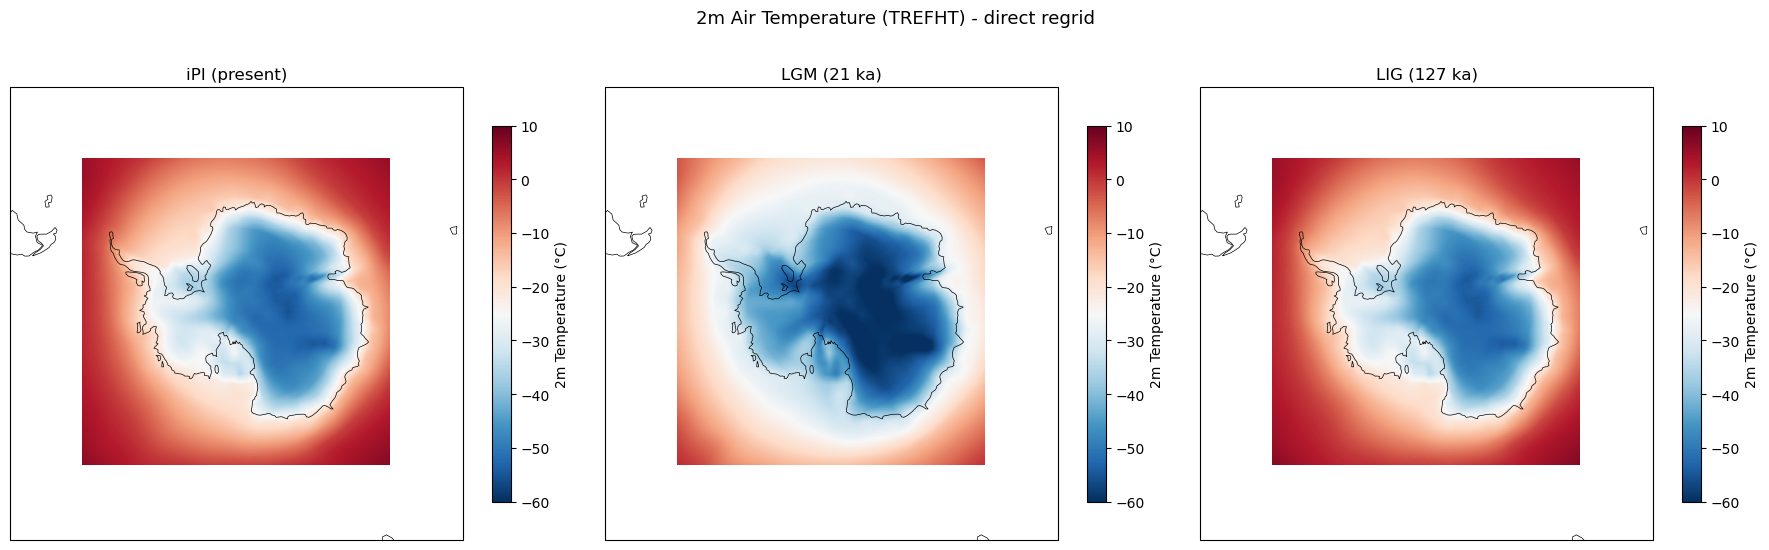

In [40]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6),
                         subplot_kw={"projection": ccrs.SouthPolarStereo()})

for ax, data, title in zip(axes,
                            [ipi_trefht_cism, lgm_trefht_cism, lig_trefht_cism],
                            ["iPI (present)", "LGM (21 ka)", "LIG (127 ka)"]):
    ax.set_extent([-180, 180, -90, -50], ccrs.PlateCarree())
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
    p = ax.pcolormesh(lon2d, lat2d, data,
                      transform=ccrs.PlateCarree(),
                      cmap="RdBu_r", vmin=-60, vmax=10)
    plt.colorbar(p, ax=ax, label="2m Temperature (°C)", shrink=0.7)
    ax.set_title(title)

plt.suptitle("2m Air Temperature (TREFHT) - direct regrid", fontsize=13)
plt.tight_layout()
plt.show()

In [52]:
from scipy.stats import norm

ipi_climo_base = ("/glade/campaign/cesm/community/palwg/iCESM1.2-DeglacialSlice/"
                  "b.e12.B1850C5.f19_g16.iPI.01/atm/climo/")

# iPI — stack 12 monthly climo files, squeeze single time dim from each
ipi_months = [xr.open_dataset(ipi_climo_base + f"b.e12.B1850C5.f19_g16.iPI.01_{m:02d}_climo.nc")
              .isel(time=0)
              for m in range(1, 13)]
ipi_monthly = xr.concat(ipi_months, dim="month").assign_coords(month=np.arange(1, 13))
ipi_monthly = ipi_monthly.sel(lat=slice(-90, -50))

ipi_trefht_mon = ipi_monthly["TREFHT"]
ipi_precip_mon = ipi_monthly["PRECC"] + ipi_monthly["PRECL"]

print("iPI monthly TREFHT shape:", ipi_trefht_mon.shape)  # expect (12, 22, 144)

# LGM — group last-100yr tseries by month
lgm_precc_ds   = xr.open_dataset(lgm_precip_base + "PRECC/b.e12.B1850C5.f19_g16.i21ka.03.cam.h0.PRECC.0001-0900.nc", use_cftime=True)
lgm_precl_ds   = xr.open_dataset(lgm_precip_base + "PRECL/b.e12.B1850C5.f19_g16.i21ka.03.cam.h0.PRECL.0001-0900.nc", use_cftime=True)
lgm_trefht_ds  = xr.open_dataset(lgm_precip_base + "TREFHT/b.e12.B1850C5.f19_g16.i21ka.03.cam.h0.TREFHT.0001-0900.nc", use_cftime=True)

lgm_trefht_mon = (lgm_trefht_ds["TREFHT"].isel(time=slice(-1200, None))
                  .sel(lat=slice(-90, -50)).groupby("time.month").mean("time"))
lgm_precip_mon = ((lgm_precc_ds["PRECC"] + lgm_precl_ds["PRECL"]).isel(time=slice(-1200, None))
                  .sel(lat=slice(-90, -50)).groupby("time.month").mean("time"))

print("LGM monthly TREFHT shape:", lgm_trefht_mon.shape)  # expect (12, 22, 144)

# LIG — group 451-501yr tseries by month
lig_precc_ds   = xr.open_dataset(lig_precip_base + "b.e12.B1850C5.f19_g16.iLIG127k.001.cam.h0.PRECC.045101-050012.nc", use_cftime=True)
lig_precl_ds   = xr.open_dataset(lig_precip_base + "b.e12.B1850C5.f19_g16.iLIG127k.001.cam.h0.PRECL.045101-050012.nc", use_cftime=True)
lig_trefht_ds  = xr.open_dataset(lig_precip_base + "b.e12.B1850C5.f19_g16.iLIG127k.001.cam.h0.TREFHT.045101-050012.nc", use_cftime=True)

lig_trefht_mon = (lig_trefht_ds["TREFHT"]
                  .sel(lat=slice(-90, -50)).groupby("time.month").mean("time"))
lig_precip_mon = ((lig_precc_ds["PRECC"] + lig_precl_ds["PRECL"])
                  .sel(lat=slice(-90, -50)).groupby("time.month").mean("time"))

print("LIG monthly TREFHT shape:", lig_trefht_mon.shape)  # expect (12, 22, 144)

iPI monthly TREFHT shape: (12, 22, 144)


/glade/derecho/scratch/advike/tmp/ipykernel_3255/2616052924.py:19: DeprecationWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg instead.
Example usage:
    time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
    ds = xr.open_dataset(decode_times=time_coder)

  lgm_precc_ds   = xr.open_dataset(lgm_precip_base + "PRECC/b.e12.B1850C5.f19_g16.i21ka.03.cam.h0.PRECC.0001-0900.nc", use_cftime=True)
/glade/derecho/scratch/advike/tmp/ipykernel_3255/2616052924.py:20: DeprecationWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg instead.
Example usage:
    time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
    ds = xr.open_dataset(decode_times=time_coder)

  lgm_precl_ds   = xr.open_dataset(lgm_precip_base + "PRECL/b.e12.B1850C5.f19_g16.i21ka.03.cam.h0.PRECL.0001-0900.nc", use_cft

LGM monthly TREFHT shape: (12, 22, 144)


/glade/derecho/scratch/advike/tmp/ipykernel_3255/2616052924.py:31: DeprecationWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg instead.
Example usage:
    time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
    ds = xr.open_dataset(decode_times=time_coder)

  lig_precc_ds   = xr.open_dataset(lig_precip_base + "b.e12.B1850C5.f19_g16.iLIG127k.001.cam.h0.PRECC.045101-050012.nc", use_cftime=True)
/glade/derecho/scratch/advike/tmp/ipykernel_3255/2616052924.py:32: DeprecationWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg instead.
Example usage:
    time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
    ds = xr.open_dataset(decode_times=time_coder)

  lig_precl_ds   = xr.open_dataset(lig_precip_base + "b.e12.B1850C5.f19_g16.iLIG127k.001.cam.h0.PRECL.045101-050012.nc", use

LIG monthly TREFHT shape: (12, 22, 144)


In [53]:
def regrid_monthly(da_mon, varname, label):
    """Regrid a (month, lat, lon) DataArray to CISM grid, return (12, 761, 761) numpy array."""
    out = np.zeros((12, 761, 761))
    src = xr.Dataset({varname: da_mon.isel(month=0)})
    rgr = xe.Regridder(src, grid_cism, method="bilinear", periodic=True)
    for m in range(12):
        src_m = xr.Dataset({varname: da_mon.isel(month=m)})
        out[m] = rgr(src_m)[varname].values
    print(f"{label} {varname}: regridded shape {out.shape}")
    return out

ipi_trefht_cism_mon = regrid_monthly(ipi_trefht_mon, "TREFHT", "iPI")   # K
lgm_trefht_cism_mon = regrid_monthly(lgm_trefht_mon, "TREFHT", "LGM")
lig_trefht_cism_mon = regrid_monthly(lig_trefht_mon, "TREFHT", "LIG")

ipi_precip_cism_mon = regrid_monthly(ipi_precip_mon, "PRECIP", "iPI")   # m/s
lgm_precip_cism_mon = regrid_monthly(lgm_precip_mon, "PRECIP", "LGM")
lig_precip_cism_mon = regrid_monthly(lig_precip_mon, "PRECIP", "LIG")

iPI TREFHT: regridded shape (12, 761, 761)
LGM TREFHT: regridded shape (12, 761, 761)
LIG TREFHT: regridded shape (12, 761, 761)
iPI PRECIP: regridded shape (12, 761, 761)
LGM PRECIP: regridded shape (12, 761, 761)
LIG PRECIP: regridded shape (12, 761, 761)


In [54]:
# Zheng et al. (2023) parameters — Antarctica-specific, calibrated against satellite + RACMO
T0              = -2.6    # melt threshold °C
DDF             = 1.9     # mm w.e. °C⁻¹ d⁻¹
SIGMA           = 5.0     # °C sub-monthly temperature variability (Reeh 1991)
T_RS            = 2.0     # °C rain/snow partitioning threshold
PMAX            = 0.6     # refreezing fraction (Reeh 1991)
DAYS_PER_MONTH  = np.array([31, 28, 31, 30, 31, 30, 31, 31, 30, 31, 30, 31], dtype=float)

def calov_greve_pdd(T_rel, sigma):
    """
    Calov & Greve (2005) analytical expectation of max(T-T0, 0) under N(T_rel, sigma^2).
    T_rel = T_monthly_C - T0. Returns °C — multiply by days-in-month to get °C·day.
    """
    return sigma * norm.pdf(T_rel / sigma) + T_rel * norm.cdf(T_rel / sigma)

# Sanity check before running
print("Cold month (-30°C mean, T0=-2.6):", calov_greve_pdd(np.array([-27.4]), SIGMA))  # near 0
print("Warm month (+5°C mean, T0=-2.6):",  calov_greve_pdd(np.array([7.6]),   SIGMA))  # near 7.6
print("Threshold (T=T0):",                 calov_greve_pdd(np.array([0.0]),   SIGMA))  # sigma/sqrt(2pi) ≈ 2.0

def pdd_smb(trefht_mon_K, precip_mon_ms, label):
    """
    Compute annual SMB (mm w.e./yr) from monthly T2m and precip.
    trefht_mon_K : (12, 761, 761) K
    precip_mon_ms: (12, 761, 761) m/s
    """
    shape = trefht_mon_K.shape[1:]
    annual_snow = np.zeros(shape)
    annual_pdd  = np.zeros(shape)

    for m in range(12):
        T_C  = trefht_mon_K[m] - 273.15       # K → °C
        P_md = precip_mon_ms[m] * 86400e3     # m/s → mm/day

        # Snow accumulation (mm w.e./month)
        snow_frac    = np.where(T_C < T_RS, 1.0, 0.0)
        annual_snow += P_md * snow_frac * DAYS_PER_MONTH[m]

        # PDDs (°C·day/month) via Calov-Greve integral
        T_rel        = T_C - T0
        annual_pdd  += calov_greve_pdd(T_rel, SIGMA) * DAYS_PER_MONTH[m]

    annual_melt = DDF * annual_pdd                                    # mm w.e./yr
    refreeze    = np.minimum(PMAX * annual_snow, annual_melt)         # mm w.e./yr
    smb         = annual_snow - annual_melt + refreeze                # mm w.e./yr

    print(f"{label} annual snow:  {np.nanmean(annual_snow):.1f} mm/yr")
    print(f"{label} annual PDD:   {np.nanmean(annual_pdd):.2f} °C·day")
    print(f"{label} annual melt:  {np.nanmean(annual_melt):.1f} mm/yr")
    print(f"{label} SMB:          {np.nanmean(smb):.1f} mm/yr  "
          f"(range: {np.nanmin(smb):.1f} to {np.nanmax(smb):.1f})")
    return smb

ipi_smb_pdd = pdd_smb(ipi_trefht_cism_mon, ipi_precip_cism_mon, "iPI")
lgm_smb_pdd = pdd_smb(lgm_trefht_cism_mon, lgm_precip_cism_mon, "LGM")
lig_smb_pdd = pdd_smb(lig_trefht_cism_mon, lig_precip_cism_mon, "LIG")

Cold month (-30°C mean, T0=-2.6): [1.82857443e-08]
Warm month (+5°C mean, T0=-2.6): [7.73998148]
Threshold (T=T0): [1.9947114]
iPI annual snow:  436.8 mm/yr
iPI annual PDD:   543.57 °C·day
iPI annual melt:  1032.8 mm/yr
iPI SMB:          -388.0 mm/yr  (range: -6729.5 to 1231.6)
LGM annual snow:  326.8 mm/yr
LGM annual PDD:   82.32 °C·day
LGM annual melt:  156.4 mm/yr
LGM SMB:          275.5 mm/yr  (range: -2318.5 to 954.1)
LIG annual snow:  433.6 mm/yr
LIG annual PDD:   546.97 °C·day
LIG annual melt:  1039.2 mm/yr
LIG SMB:          -407.0 mm/yr  (range: -6803.4 to 1185.6)


iPI SMB (ice only): 178.8 mm/yr
LGM SMB (ice only): 73.7 mm/yr
LIG SMB (ice only): 176.0 mm/yr


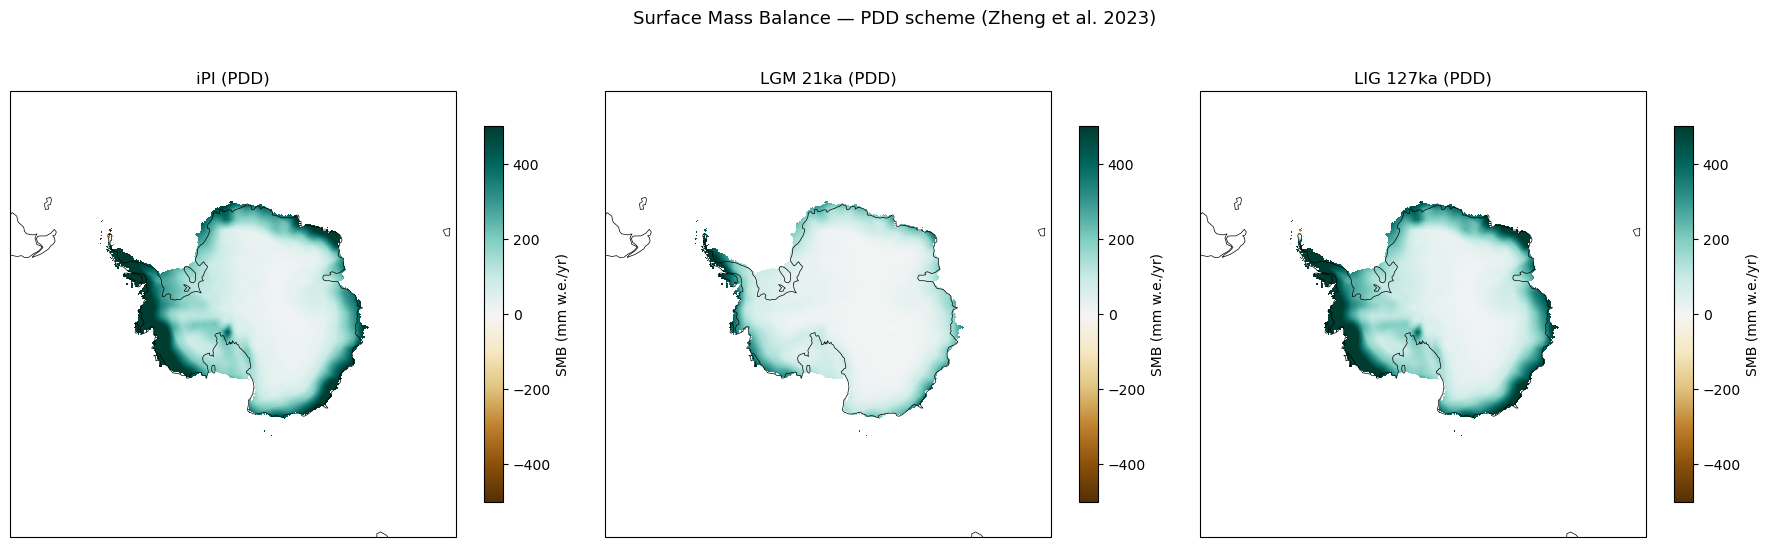

In [55]:
# Load ice mask from ref file — mask out ocean cells (where ref_smb is NaN)
ice_mask = np.isfinite(ref_smb)   # True over ice, False over ocean

ipi_smb_pdd_masked = np.where(ice_mask, ipi_smb_pdd, np.nan)
lgm_smb_pdd_masked = np.where(ice_mask, lgm_smb_pdd, np.nan)
lig_smb_pdd_masked = np.where(ice_mask, lig_smb_pdd, np.nan)

print(f"iPI SMB (ice only): {np.nanmean(ipi_smb_pdd_masked):.1f} mm/yr")
print(f"LGM SMB (ice only): {np.nanmean(lgm_smb_pdd_masked):.1f} mm/yr")
print(f"LIG SMB (ice only): {np.nanmean(lig_smb_pdd_masked):.1f} mm/yr")

fig, axes = plt.subplots(1, 3, figsize=(18, 6),
                         subplot_kw={"projection": ccrs.SouthPolarStereo()})

for ax, data, title in zip(axes,
                            [ipi_smb_pdd_masked, lgm_smb_pdd_masked, lig_smb_pdd_masked],
                            ["iPI (PDD)", "LGM 21ka (PDD)", "LIG 127ka (PDD)"]):
    ax.set_extent([-180, 180, -90, -50], ccrs.PlateCarree())
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
    p = ax.pcolormesh(lon2d, lat2d, data,
                      transform=ccrs.PlateCarree(),
                      cmap="BrBG", vmin=-500, vmax=500)
    plt.colorbar(p, ax=ax, label="SMB (mm w.e./yr)", shrink=0.7)
    ax.set_title(title)

plt.suptitle("Surface Mass Balance — PDD scheme (Zheng et al. 2023)", fontsize=13)
plt.tight_layout()
plt.show()

In [56]:
print(f"RACMO PD SMB mean (ice only):        {np.nanmean(ref_smb[ice_mask]):.1f} mm/yr")
print(f"Anomaly method LGM SMB (ice only):   {np.nanmean(lgm_smb_final[ice_mask]):.1f} mm/yr")
print(f"PDD method LGM SMB (ice only):       {np.nanmean(lgm_smb_pdd_masked[ice_mask]):.1f} mm/yr")
print(f"Anomaly method LIG SMB (ice only):   {np.nanmean(lig_smb_final[ice_mask]):.1f} mm/yr")
print(f"PDD method LIG SMB (ice only):       {np.nanmean(lig_smb_pdd_masked[ice_mask]):.1f} mm/yr")

RACMO PD SMB mean (ice only):        182.4 mm/yr
Anomaly method LGM SMB (ice only):   75.3 mm/yr
PDD method LGM SMB (ice only):       73.7 mm/yr
Anomaly method LIG SMB (ice only):   178.8 mm/yr
PDD method LIG SMB (ice only):       176.0 mm/yr


In [57]:
# Save all forcing files to output directory
# Dimensions match ref file: (y1, x1) = (761, 761)

def save_forcing(data_np, varname, units, long_name, period_label, method, filename):
    da = xr.DataArray(
        data_np,
        dims=["y1", "x1"],
        attrs={
            "long_name": long_name,
            "units": units,
            "period": period_label,
            "method": method,
        }
    )
    ds = xr.Dataset({varname: da})
    outpath = os.path.join(out_dir, filename)
    ds.to_netcdf(outpath)
    print(f"Saved: {filename}")

# ── Surface temperature (TS anomaly method) ────────────────────────────────────
save_forcing(lgm_artm_final, "artm", "degC",
             "Surface air temperature (TS anomaly method)",
             "LGM 21ka", "RACMO PD artm + iCESM TS anomaly relative to iPI",
             "lgm21ka_artm_on_cism8km.nc")

save_forcing(lig_artm_final, "artm", "degC",
             "Surface air temperature (TS anomaly method)",
             "LIG 127ka", "RACMO PD artm + iCESM TS anomaly relative to iPI",
             "lig127ka_artm_on_cism8km.nc")

# ── 2m temperature (TREFHT direct regrid) ─────────────────────────────────────
save_forcing(ipi_trefht_cism, "trefht", "degC",
             "2m air temperature (direct regrid)",
             "iPI", "iCESM iPI TREFHT bilinear regrid to CISM 8km",
             "ipi_trefht_on_cism8km.nc")

save_forcing(lgm_trefht_cism, "trefht", "degC",
             "2m air temperature (direct regrid)",
             "LGM 21ka", "iCESM LGM TREFHT bilinear regrid to CISM 8km, last-100yr mean",
             "lgm21ka_trefht_on_cism8km.nc")

save_forcing(lig_trefht_cism, "trefht", "degC",
             "2m air temperature (direct regrid)",
             "LIG 127ka", "iCESM LIG TREFHT bilinear regrid to CISM 8km, yr451-501 mean",
             "lig127ka_trefht_on_cism8km.nc")

# ── SMB anomaly method ─────────────────────────────────────────────────────────
save_forcing(lgm_smb_final, "acab", "mm w.e. yr-1",
             "Surface mass balance (precip anomaly method)",
             "LGM 21ka", "RACMO PD SMB + iCESM PRECIP anomaly relative to iPI",
             "lgm21ka_acab_anomaly_on_cism8km.nc")

save_forcing(lig_smb_final, "acab", "mm w.e. yr-1",
             "Surface mass balance (precip anomaly method)",
             "LIG 127ka", "RACMO PD SMB + iCESM PRECIP anomaly relative to iPI",
             "lig127ka_acab_anomaly_on_cism8km.nc")

# ── SMB PDD method ─────────────────────────────────────────────────────────────
save_forcing(lgm_smb_pdd_masked, "acab", "mm w.e. yr-1",
             "Surface mass balance (PDD scheme, Zheng et al. 2023)",
             "LGM 21ka",
             "PDD: T0=-2.6C, DDF=1.9 mm/C/day, sigma=5C, Pmax=0.6, T_rs=2C; iCESM TREFHT+PRECIP",
             "lgm21ka_acab_pdd_on_cism8km.nc")

save_forcing(lig_smb_pdd_masked, "acab", "mm w.e. yr-1",
             "Surface mass balance (PDD scheme, Zheng et al. 2023)",
             "LIG 127ka",
             "PDD: T0=-2.6C, DDF=1.9 mm/C/day, sigma=5C, Pmax=0.6, T_rs=2C; iCESM TREFHT+PRECIP",
             "lig127ka_acab_pdd_on_cism8km.nc")

# ── Verify all files saved ─────────────────────────────────────────────────────
print("\nAll files in output dir:")
for f in sorted(os.listdir(out_dir)):
    print(f"  {f}")

Saved: lgm21ka_artm_on_cism8km.nc
Saved: lig127ka_artm_on_cism8km.nc
Saved: ipi_trefht_on_cism8km.nc
Saved: lgm21ka_trefht_on_cism8km.nc
Saved: lig127ka_trefht_on_cism8km.nc
Saved: lgm21ka_acab_anomaly_on_cism8km.nc
Saved: lig127ka_acab_anomaly_on_cism8km.nc
Saved: lgm21ka_acab_pdd_on_cism8km.nc
Saved: lig127ka_acab_pdd_on_cism8km.nc

All files in output dir:
  Antarctica_8km.cfinput.lgm21ka.nc
  Antarctica_8km.cfinput.lig127ka.nc
  Antarctica_8km.restart.lgm21ka.nc
  Antarctica_8km.restart.lig127ka.nc
  CISM3_initialization_AIS_08000.lgm21ka.nc
  CISM3_initialization_AIS_08000.lig127ka.nc
  ipi_trefht_on_cism8km.nc
  lgm21ka_acab_anomaly_on_cism8km.nc
  lgm21ka_acab_pdd_on_cism8km.nc
  lgm21ka_artm_on_cism8km.nc
  lgm21ka_atm_PRECIP_on_cism8km.nc
  lgm21ka_atm_TREFHT_on_cism8km.nc
  lgm21ka_ocn_thermal_forcing_on_cism8km.nc
  lgm21ka_to_cism8km_atm_precip_regridder.nc
  lgm21ka_to_cism8km_atm_regridder.nc
  lgm21ka_to_cism8km_pop_regridder.nc
  lgm21ka_trefht_on_cism8km.nc
  lig127ka_

In [61]:
tf_lgm = xr.open_dataset(out_dir + "lgm21ka_ocn_thermal_forcing_on_cism8km.nc")
print(tf_lgm)

<xarray.Dataset> Size: 839MB
Dimensions:          (time: 12, zocn: 30, y1: 761, x1: 761)
Coordinates:
  * time             (time) float64 96B 0.0 0.08333 0.1667 ... 0.8333 0.9167
    lat              (y1, x1) float32 2MB ...
    lon              (y1, x1) float32 2MB ...
  * zocn             (zocn) float32 120B -30.0 -90.0 ... -1.71e+03 -1.77e+03
Dimensions without coordinates: y1, x1
Data variables:
    thermal_forcing  (time, zocn, y1, x1) float32 834MB ...


In [66]:
# Recompute unmasked PDD SMB (ocean cells retain their values, no NaN masking)
# lgm_smb_pdd and lig_smb_pdd are already unmasked from pdd_smb() — just use those directly
print(f"LGM PDD SMB unmasked mean: {np.nanmean(lgm_smb_pdd):.1f} mm/yr")
print(f"LIG PDD SMB unmasked mean: {np.nanmean(lig_smb_pdd):.1f} mm/yr")

# Overwrite the saved PDD files with unmasked versions
save_forcing(lgm_smb_pdd, "acab", "mm w.e. yr-1",
             "Surface mass balance (PDD scheme, Zheng et al. 2023)",
             "LGM 21ka",
             "PDD: T0=-2.6C, DDF=1.9 mm/C/day, sigma=5C, Pmax=0.6, T_rs=2C; iCESM TREFHT+PRECIP",
             "lgm21ka_acab_pdd_on_cism8km.nc")

save_forcing(lig_smb_pdd, "acab", "mm w.e. yr-1",
             "Surface mass balance (PDD scheme, Zheng et al. 2023)",
             "LIG 127ka",
             "PDD: T0=-2.6C, DDF=1.9 mm/C/day, sigma=5C, Pmax=0.6, T_rs=2C; iCESM TREFHT+PRECIP",
             "lig127ka_acab_pdd_on_cism8km.nc")

LGM PDD SMB unmasked mean: 275.5 mm/yr
LIG PDD SMB unmasked mean: -407.0 mm/yr
Saved: lgm21ka_acab_pdd_on_cism8km.nc
Saved: lig127ka_acab_pdd_on_cism8km.nc


In [68]:
import copy

def build_cism_forcing(artm_np, smb_np, tf_ann_np, period_label, method_artm, method_smb, filename):
    """
    Build a complete CISM forcing file by copying the PD ref file structure
    and replacing artm, smb, and thermal_forcing with paleo fields.
    All geometry/bed/velocity fields are taken unchanged from the PD ref file.
    
    tf_ann_np: (zocn, y1, x1) annual mean thermal forcing, float64, fill=-99999
    """
    # Start from ref dataset, copy all variables
    ds_out = xr.Dataset()

    # Copy all variables from ref unchanged except the three forcing fields
    skip = {"artm", "smb", "thermal_forcing"}
    for v in ref.data_vars:
        if v not in skip:
            ds_out[v] = ref[v].copy()

    # ── artm ──────────────────────────────────────────────────────────────────
    artm_fill = artm_np.copy()
    artm_fill = np.where(np.isnan(artm_fill), -9999., artm_fill)
    ds_out["artm"] = xr.DataArray(
        artm_fill[np.newaxis, :, :].astype("float32"),   # add time dim
        dims=["time", "y1", "x1"],
        attrs={
            "standard_name": "surface_air_temperature",
            "long_name": f"Annual surface air temperature ({period_label})",
            "units": "degree celsius",
            "source": "iCESM1.2",
            "method": method_artm,
        }
    )

    # ── smb ───────────────────────────────────────────────────────────────────
    smb_fill = smb_np.copy()
    smb_fill = np.where(np.isnan(smb_fill), -9999., smb_fill)
    ds_out["smb"] = xr.DataArray(
        smb_fill[np.newaxis, :, :].astype("float32"),
        dims=["time", "y1", "x1"],
        attrs={
            "standard_name": "surface_mass_balance",
            "long_name": f"Annual SMB ({period_label})",
            "units": "mm/yr water equivalent",
            "source": "iCESM1.2",
            "method": method_smb,
        }
    )

    # ── thermal_forcing ───────────────────────────────────────────────────────
    ds_out["thermal_forcing"] = xr.DataArray(
        tf_ann_np[np.newaxis, :, :, :].astype("float32"),  # add time dim → (1, zocn, y1, x1)
        dims=["time", "zocn", "y1", "x1"],
        attrs={
            "long_name": f"Thermal forcing ({period_label})",
            "units": "degree celsius",
            "interpolation": "bilinear",
            "note": "Annual mean of monthly climatology; unphysical values set to -99999",
            "method": "iCESM1.2 POP2 anomaly + WOA PD, depth-varying",
        }
    )

    # ── global attributes ─────────────────────────────────────────────────────
    ds_out.attrs = dict(ref.attrs)
    ds_out.attrs["period"] = period_label
    ds_out.attrs["artm_method"] = method_artm
    ds_out.attrs["smb_method"] = method_smb
    ds_out.attrs["history"] = f"Created from iCESM1.2 paleo forcing; PD geometry from {ref_path}"

    outpath = os.path.join(out_dir, filename)
    ds_out.to_netcdf(outpath)
    print(f"Saved: {filename}")
    return ds_out

# Prepare annual mean thermal forcing (zocn, y1, x1), preserving -99999 fill
tf_lgm_ann = tf_lgm["thermal_forcing"].mean("time").values.astype("float64")
tf_lig_ann = tf_lig["thermal_forcing"].mean("time").values.astype("float64")

# Build LGM files — one for each SMB method
ds_lgm_pdd = build_cism_forcing(
    lgm_artm_final, lgm_smb_pdd, tf_lgm_ann,
    "LGM 21ka",
    "RACMO PD artm + iCESM TS anomaly relative to iPI",
    "PDD scheme: Zheng et al. 2023 (T0=-2.6C, DDF=1.9, sigma=5C)",
    "CISM3_forcing_AIS_08000.lgm21ka.pdd.nc"
)

ds_lgm_anom = build_cism_forcing(
    lgm_artm_final, lgm_smb_final, tf_lgm_ann,
    "LGM 21ka",
    "RACMO PD artm + iCESM TS anomaly relative to iPI",
    "Precip anomaly method: RACMO PD SMB + iCESM PRECIP anomaly relative to iPI",
    "CISM3_forcing_AIS_08000.lgm21ka.anomaly.nc"
)

# Build LIG files
ds_lig_pdd = build_cism_forcing(
    lig_artm_final, lig_smb_pdd, tf_lig_ann,
    "LIG 127ka",
    "RACMO PD artm + iCESM TS anomaly relative to iPI",
    "PDD scheme: Zheng et al. 2023 (T0=-2.6C, DDF=1.9, sigma=5C)",
    "CISM3_forcing_AIS_08000.lig127ka.pdd.nc"
)

ds_lig_anom = build_cism_forcing(
    lig_artm_final, lig_smb_final, tf_lig_ann,
    "LIG 127ka",
    "RACMO PD artm + iCESM TS anomaly relative to iPI",
    "Precip anomaly method: RACMO PD SMB + iCESM PRECIP anomaly relative to iPI",
    "CISM3_forcing_AIS_08000.lig127ka.anomaly.nc"
)

Saved: CISM3_forcing_AIS_08000.lgm21ka.pdd.nc
Saved: CISM3_forcing_AIS_08000.lgm21ka.anomaly.nc
Saved: CISM3_forcing_AIS_08000.lig127ka.pdd.nc
Saved: CISM3_forcing_AIS_08000.lig127ka.anomaly.nc


In [73]:
# Revert to ice-masked PDD SMB
save_forcing(lgm_smb_pdd_masked, "acab", "mm w.e. yr-1",
             "Surface mass balance (PDD scheme, Zheng et al. 2023)",
             "LGM 21ka",
             "PDD: T0=-2.6C, DDF=1.9 mm/C/day, sigma=5C, Pmax=0.6, T_rs=2C; iCESM TREFHT+PRECIP",
             "lgm21ka_acab_pdd_on_cism8km.nc")

save_forcing(lig_smb_pdd_masked, "acab", "mm w.e. yr-1",
             "Surface mass balance (PDD scheme, Zheng et al. 2023)",
             "LIG 127ka",
             "PDD: T0=-2.6C, DDF=1.9 mm/C/day, sigma=5C, Pmax=0.6, T_rs=2C; iCESM TREFHT+PRECIP",
             "lig127ka_acab_pdd_on_cism8km.nc")

# Rebuild CISM forcing files with masked PDD SMB
ds_lgm_pdd = build_cism_forcing(
    lgm_artm_final, lgm_smb_pdd_masked, tf_lgm_ann,
    "LGM 21ka",
    "RACMO PD artm + iCESM TS anomaly relative to iPI",
    "PDD scheme: Zheng et al. 2023 (T0=-2.6C, DDF=1.9, sigma=5C); masked to RACMO ice domain",
    "CISM3_forcing_AIS_08000.lgm21ka.pdd.nc"
)

ds_lig_pdd = build_cism_forcing(
    lig_artm_final, lig_smb_pdd_masked, tf_lig_ann,
    "LIG 127ka",
    "RACMO PD artm + iCESM TS anomaly relative to iPI",
    "PDD scheme: Zheng et al. 2023 (T0=-2.6C, DDF=1.9, sigma=5C); masked to RACMO ice domain",
    "CISM3_forcing_AIS_08000.lig127ka.pdd.nc"
)

print("Done — reverted to masked PDD SMB")

Saved: lgm21ka_acab_pdd_on_cism8km.nc
Saved: lig127ka_acab_pdd_on_cism8km.nc
Saved: CISM3_forcing_AIS_08000.lgm21ka.pdd.nc
Saved: CISM3_forcing_AIS_08000.lig127ka.pdd.nc
Done — reverted to masked PDD SMB


                        artm mean     smb mean      tf mean
------------------------------------------------------------
PD (ref)                   -15.7°       182.4 mm/yr     0.75°
LGM PDD                    -28.8°        73.7 mm/yr     0.28°
LGM anomaly                -28.8°        75.3 mm/yr     0.28°
LIG PDD                    -15.4°       176.0 mm/yr     2.16°
LIG anomaly                -15.4°       178.8 mm/yr     2.16°


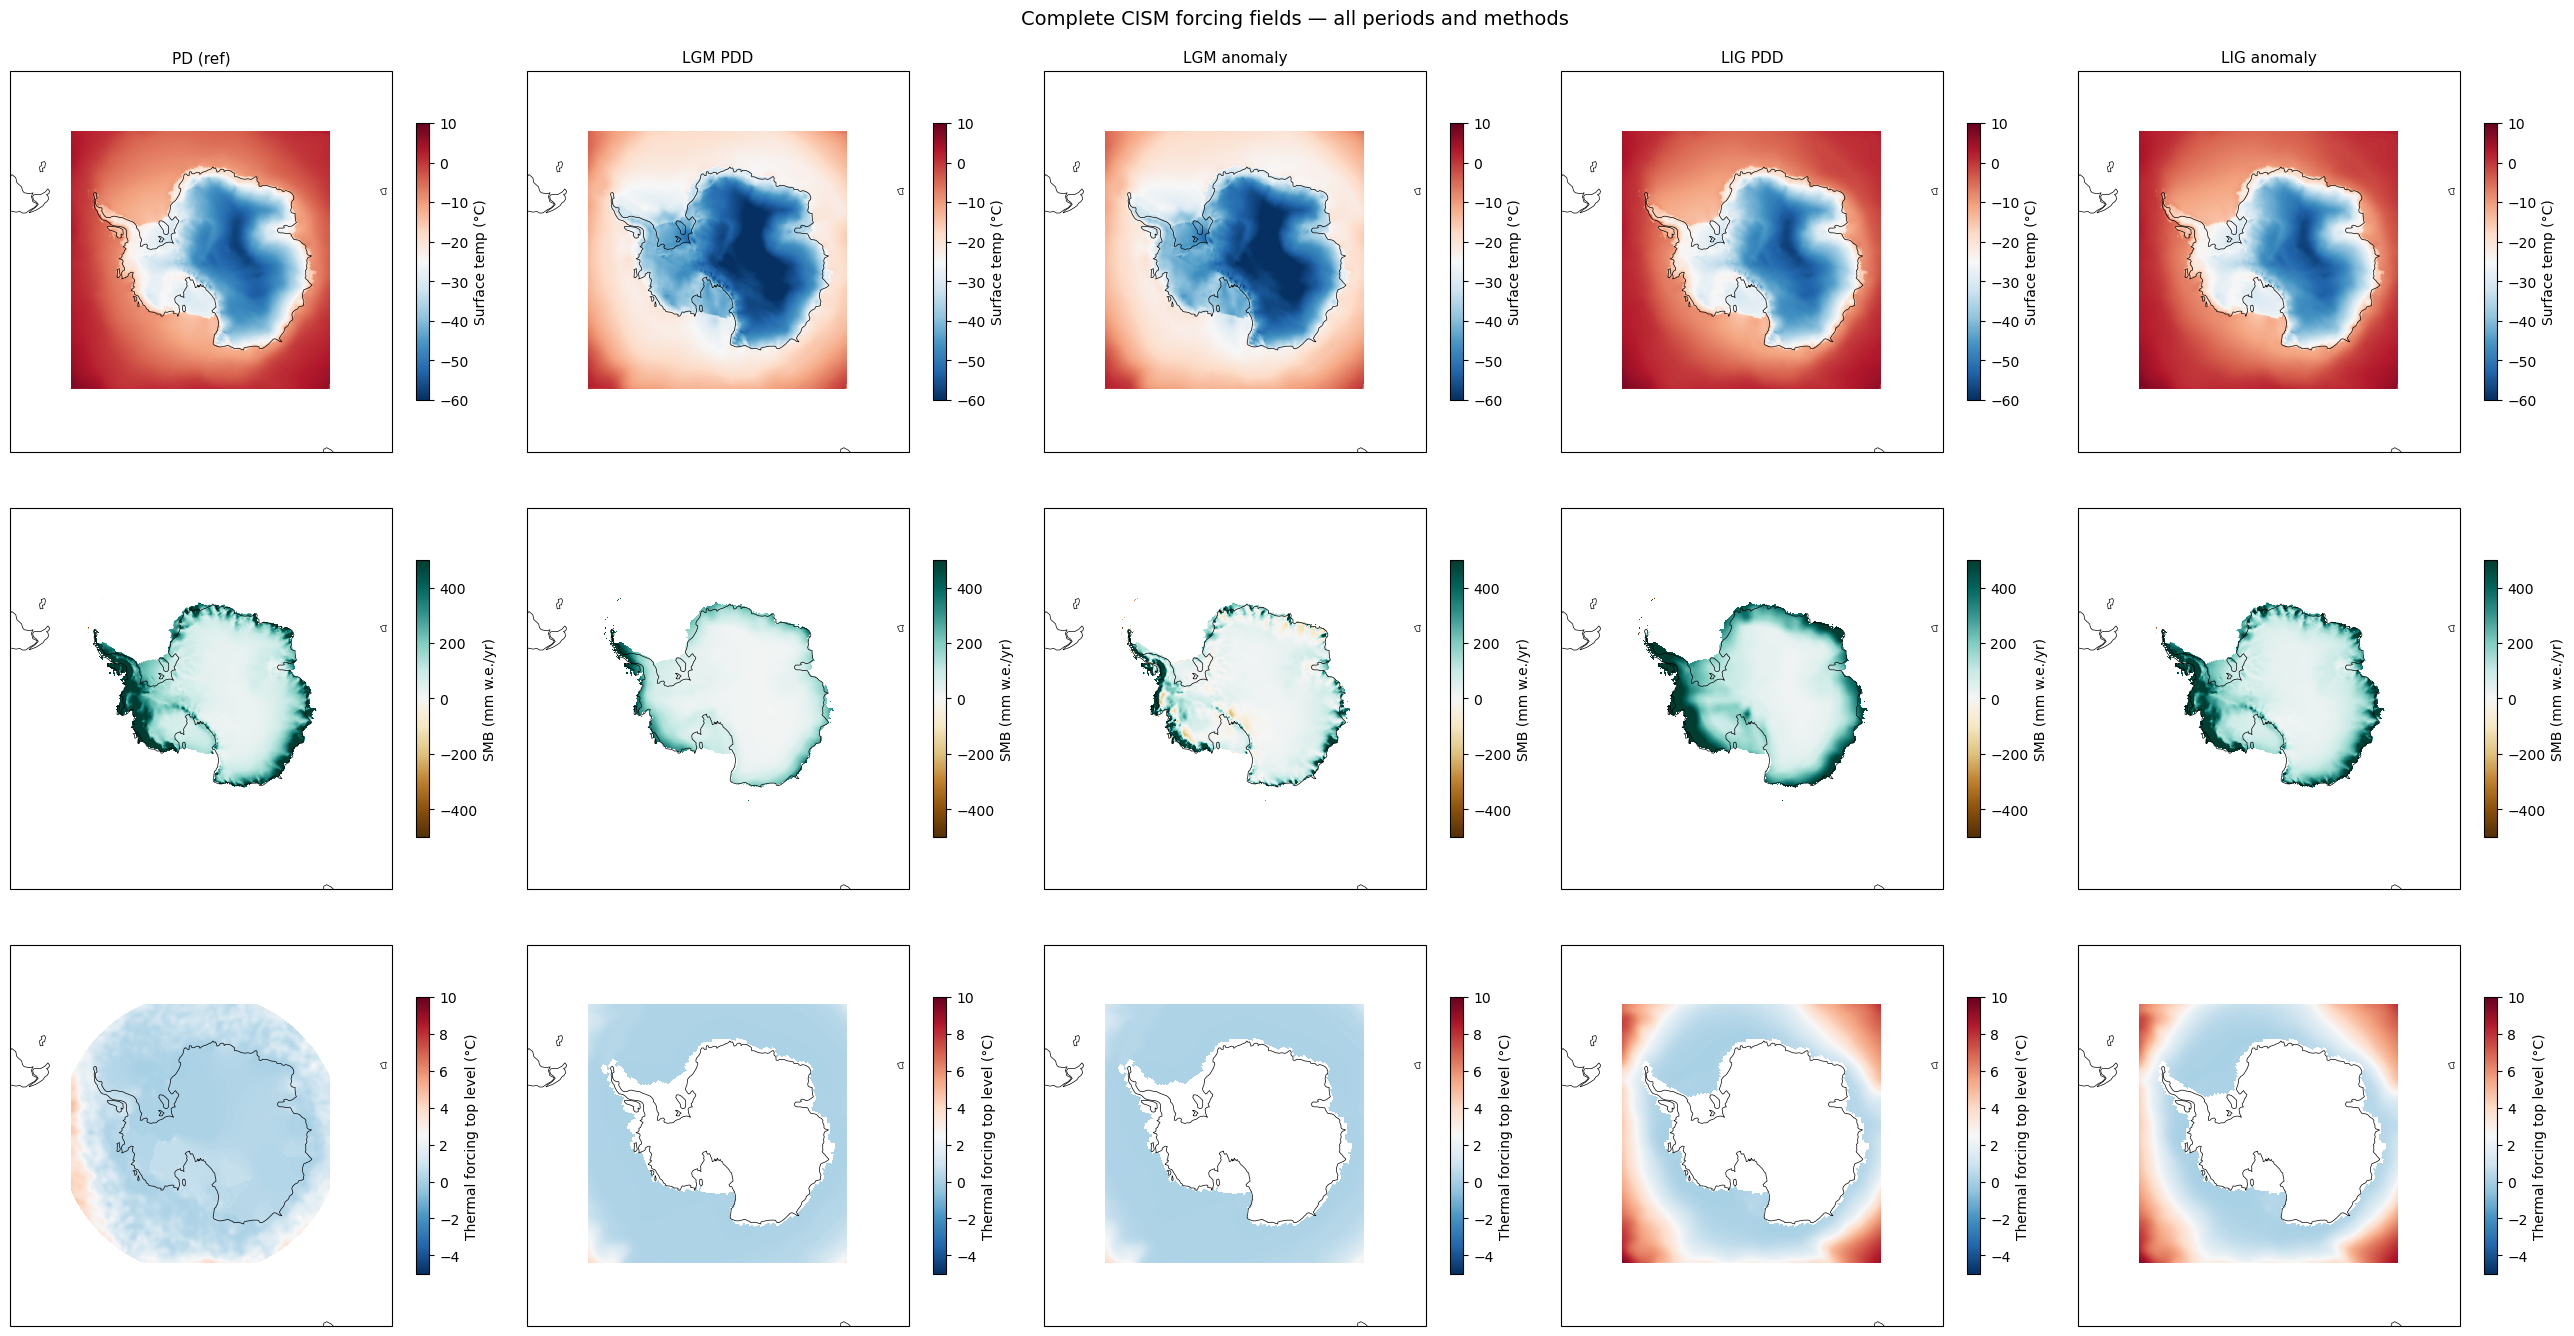

In [77]:
ds_lgm_pdd  = xr.open_dataset(out_dir + "CISM3_forcing_AIS_08000.lgm21ka.pdd.nc",     decode_cf=False)
ds_lgm_anom = xr.open_dataset(out_dir + "CISM3_forcing_AIS_08000.lgm21ka.anomaly.nc",  decode_cf=False)
ds_lig_pdd  = xr.open_dataset(out_dir + "CISM3_forcing_AIS_08000.lig127ka.pdd.nc",     decode_cf=False)
ds_lig_anom = xr.open_dataset(out_dir + "CISM3_forcing_AIS_08000.lig127ka.anomaly.nc", decode_cf=False)

def clean(arr):
    """Mask both large negative fills (-9999) and large positive fills (9.96e36)."""
    a = arr.astype("float64")
    return np.where((a <= -9999.) | (a > 1e10), np.nan, a)

# Pull all forcing fields — isel(time=0) to drop time dim for plotting
fields = {
    "PD (ref)":    {"artm": clean(ref["artm"].isel(time=0).values),
                    "smb":  clean(ref["smb"].isel(time=0).values),
                    "tf":   clean(ref["thermal_forcing"].isel(time=0, zocn=0).values)},
    "LGM PDD":     {"artm": clean(ds_lgm_pdd["artm"].isel(time=0).values),
                    "smb":  clean(ds_lgm_pdd["smb"].isel(time=0).values),
                    "tf":   clean(ds_lgm_pdd["thermal_forcing"].isel(time=0, zocn=0).values)},
    "LGM anomaly": {"artm": clean(ds_lgm_anom["artm"].isel(time=0).values),
                    "smb":  clean(ds_lgm_anom["smb"].isel(time=0).values),
                    "tf":   clean(ds_lgm_anom["thermal_forcing"].isel(time=0, zocn=0).values)},
    "LIG PDD":     {"artm": clean(ds_lig_pdd["artm"].isel(time=0).values),
                    "smb":  clean(ds_lig_pdd["smb"].isel(time=0).values),
                    "tf":   clean(ds_lig_pdd["thermal_forcing"].isel(time=0, zocn=0).values)},
    "LIG anomaly": {"artm": clean(ds_lig_anom["artm"].isel(time=0).values),
                    "smb":  clean(ds_lig_anom["smb"].isel(time=0).values),
                    "tf":   clean(ds_lig_anom["thermal_forcing"].isel(time=0, zocn=0).values)},
}

# Print summary stats
print(f"{'':20s} {'artm mean':>12s} {'smb mean':>12s} {'tf mean':>12s}")
print("-" * 60)
for label, f in fields.items():
    print(f"{label:20s} "
          f"{np.nanmean(f['artm']):>11.1f}° "
          f"{np.nanmean(f['smb']):>11.1f} mm/yr "
          f"{np.nanmean(f['tf']):>8.2f}°")

# Plot — rows: artm, smb, tf   cols: PD, LGM PDD, LGM anomaly, LIG PDD, LIG anomaly
row_configs = [
    ("artm", "RdBu_r", -60,  10,  "Surface temp (°C)"),
    ("smb",  "BrBG",   -500, 500, "SMB (mm w.e./yr)"),
    ("tf",   "RdBu_r", -5,   10,  "Thermal forcing top level (°C)"),
]

labels = list(fields.keys())
fig, axes = plt.subplots(3, 5, figsize=(26, 14),
                         subplot_kw={"projection": ccrs.SouthPolarStereo()})

for row, (varname, cmap, vmin, vmax, clabel) in enumerate(row_configs):
    for col, label in enumerate(labels):
        ax = axes[row, col]
        ax.set_extent([-180, 180, -90, -50], ccrs.PlateCarree())
        ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
        p = ax.pcolormesh(lon2d, lat2d, fields[label][varname],
                          transform=ccrs.PlateCarree(),
                          cmap=cmap, vmin=vmin, vmax=vmax)
        plt.colorbar(p, ax=ax, label=clabel, shrink=0.6)
        if row == 0:
            ax.set_title(label, fontsize=11)
        if col == 0:
            ax.set_ylabel(varname, fontsize=10)

plt.suptitle("Complete CISM forcing fields — all periods and methods", fontsize=14)
plt.tight_layout()
plt.show()